**Klasifikasi Kualitas Anggur (Wine Quality)**

Tujuan dari analisis ini adalah membangun model klasifikasi untuk memprediksi kualitas anggur (quality) berdasarkan 11 fitur kimiawi. Data training diberikan lengkap dengan label, sedangkan data testing hanya berupa fitur. Model yang digunakan adalah Random Forest dengan penanganan ketidakseimbangan kelas. Seluruh proses meliputi: Persiapan Data, Pembersihan Data, Pembuatan Model, dan Prediksi Data Uji.

**LANGKAH 1: PERSIAPAN DATA**

**1.1 Import Library**

In [1]:
import pandas as pd
import numpy as np

Penjelasan:

pandas digunakan untuk membaca, memanipulasi, dan menganalisis data dalam bentuk DataFrame.

numpy digunakan untuk operasi numerik dan array multidimensi.

Interpretasi: Kedua library merupakan fondasi utama dalam analisis data menggunakan Python.

**1.2 Load Data ke DataFrame**

In [2]:
# Baca data training (berisi fitur + quality + Id)
train_df = pd.read_csv('/content/data_training.csv')

# Baca data testing (berisi fitur + Id, tanpa quality)
test_df = pd.read_csv('/content/data_testing.csv')

**1.3 Eksplorasi Data Awal**

1.3.1 Interpretasi Data Training

In [3]:
print("="*60) #Mencetak garis pemisah sepanjang 60 karakter = untuk memisahkan bagian output agar mudah dibaca.
print("INFORMASI DATA TRAINING")
print("="*60)

print(f"\nJumlah baris (sampel)   : {train_df.shape[0]}") #train_df.shape mengembalikan tuple (baris, kolom). .shape[0] mengambil jumlah baris (sampel). Dicetak dengan format f-string.
print(f"Jumlah kolom            : {train_df.shape[1]}")   #.shape[1] mengambil jumlah kolom (fitur + target + ID).
print("\nNama kolom:")
print(train_df.columns.tolist()) #train_df.columns mengembalikan nama kolom dalam bentuk Index. .tolist() mengubahnya ke list Python agar lebih mudah dibaca.

print("\n5 baris pertama:") #Sub-judul untuk menunjukkan cuplikan data.
print(train_df.head()) #head() menampilkan 5 baris pertama DataFrame. Berguna untuk melihat isi dan format data secara visual.

print("\nTipe data setiap kolom:")
print(train_df.dtypes) #dtypes menampilkan tipe data setiap kolom (misal float64, int64, object). Memastikan tidak ada tipe yang salah.

print("\nStatistik deskriptif (ringkasan numerik):")
print(train_df.describe()) #describe() menghasilkan ringkasan statistik untuk kolom numerik: count, mean, std, min, quartil, max. Berguna untuk mendeteksi outlier dan skala data.

INFORMASI DATA TRAINING

Jumlah baris (sampel)   : 857
Jumlah kolom            : 13

Nama kolom:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

5 baris pertama:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2    

Dataset training terdiri dari 857 sampel dengan 13 kolom: 11 fitur kimiawi, 1 target 'quality' (bernilai 3 hingga 8), dan 1 kolom 'Id' sebagai identitas. Semua fitur bertipe float64 dan tidak ada missing values. Berdasarkan statistik deskriptif, fitur memiliki rentang nilai yang bervariasi (misalnya fixed acidity 4,6–15,6; alcohol 8,4–14,0), serta beberapa indikasi outlier pada residual sugar dan total sulfur dioxide. Target quality didominasi oleh kelas 5 dan 6, sehingga diperlukan penanganan ketidakseimbangan kelas pada saat pembuatan model. Secara keseluruhan, data siap untuk dilanjutkan ke tahap pembersihan dan pemodelan.

1.3.2 Interpretasi Data Testing

In [4]:
print("\n" + "="*60)
print("INFORMASI DATA TESTING")
print("="*60)

print(f"\nJumlah baris (sampel)   : {test_df.shape[0]}")
print(f"Jumlah kolom            : {test_df.shape[1]}")
print("\nNama kolom:")
print(test_df.columns.tolist())

print("\n5 baris pertama:")
print(test_df.head())

print("\nTipe data setiap kolom:")
print(test_df.dtypes)

print("\nStatistik deskriptif (ringkasan numerik):")
print(test_df.describe())


INFORMASI DATA TESTING

Jumlah baris (sampel)   : 286
Jumlah kolom            : 12

Nama kolom:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']

5 baris pertama:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            6.8              0.61         0.04             1.5      0.057   
1            6.9              0.84         0.21             4.1      0.074   
2            7.0              0.58         0.12             1.9      0.091   
3            7.8              0.48         0.68             1.7      0.415   
4           12.5              0.60         0.49             4.3      0.100   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                  5.0                  10.0  0.99525  3.42       0.60   
1                 16.0                  65.0  0.99842  3.53       0.72   
2               

Data testing terdiri dari 286 sampel dengan 12 kolom: 11 fitur kimiawi (sama seperti training) dan 1 kolom 'Id' sebagai identitas. Tidak terdapat kolom target 'quality' karena data ini digunakan untuk prediksi. Semua fitur bertipe float64 dan tidak ada missing values. Statistik deskriptif menunjukkan rentang nilai fitur yang mirip dengan data training (misalnya fixed acidity 5,0–15,9; alcohol 8,4–14,9). Dengan demikian, data testing siap digunakan untuk diprediksi oleh model yang akan dibangun.

**1.4 Identifikasi Variabel (Fitur, Target, dan ID)**

In [5]:
# Data training memiliki kolom 'quality' sebagai target dan 'Id' sebagai identifier
target_col = 'quality'
id_col = 'Id'

# Fitur adalah semua kolom selain target dan Id
feature_cols = [col for col in train_df.columns if col not in [target_col, id_col]]

print("="*60)
print("IDENTIFIKASI VARIABEL")
print("="*60)
print(f"Kolom target  : {target_col}")
print(f"Kolom ID      : {id_col}")
print(f"Jumlah fitur  : {len(feature_cols)}")
print("Nama fitur:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

IDENTIFIKASI VARIABEL
Kolom target  : quality
Kolom ID      : Id
Jumlah fitur  : 11
Nama fitur:
  1. fixed acidity
  2. volatile acidity
  3. citric acid
  4. residual sugar
  5. chlorides
  6. free sulfur dioxide
  7. total sulfur dioxide
  8. density
  9. pH
  10. sulphates
  11. alcohol


**1.5 Pemisahan Fitur dan Target (Data Training)**

In [6]:
# X = fitur, y = target
X_train = train_df[feature_cols]
y_train = train_df[target_col]
id_train = train_df[id_col]   # ID training (tidak dipakai untuk latih, hanya referensi)

print("="*60)
print("PEMISAHAN FITUR DAN TARGET (DATA TRAINING)")
print("="*60)
print(f"X_train shape: {X_train.shape} (baris, fitur)")
print(f"y_train shape: {y_train.shape}")
print(f"Contoh nilai target (10 pertama):\n{y_train.head(10).values}")

PEMISAHAN FITUR DAN TARGET (DATA TRAINING)
X_train shape: (857, 11) (baris, fitur)
y_train shape: (857,)
Contoh nilai target (10 pertama):
[5 5 7 6 6 5 7 6 6 6]


Setelah variabel diidentifikasi, data training dipisahkan menjadi X_train (fitur) dan y_train (target). X_train memiliki ukuran 857×11, sesuai dengan jumlah sampel dan jumlah fitur kimiawi. y_train adalah array satu dimensi berisi nilai quality dari 3 hingga 8. Contoh 10 nilai pertama menunjukkan variasi kelas 5,6,7, yang mengindikasikan perlunya penanganan ketidakseimbangan kelas. Pemisahan ini memastikan bahwa model akan belajar dari fitur-fitur tanpa dipengaruhi oleh kolom Id (yang hanya sebagai pengenal).

**1.6 Persiapan Data Testing (Fitur dan ID)**


In [7]:
# Data testing hanya memiliki fitur dan Id (tidak ada target)
X_test = test_df[feature_cols]
id_test = test_df[id_col]

print("="*60)
print("PERSIAPAN DATA TESTING")
print("="*60)
print(f"X_test shape: {X_test.shape} (baris, fitur)")
print(f"Jumlah sampel testing: {len(id_test)}")
print(f"Contoh ID testing (10 pertama):\n{id_test.head(10).values}")

PERSIAPAN DATA TESTING
X_test shape: (286, 11) (baris, fitur)
Jumlah sampel testing: 286
Contoh ID testing (10 pertama):
[ 222 1514  417  754  516 1120  180   82  632  592]


Untuk data testing, dilakukan pemisahan serupa: X_test berisi 286 sampel dengan 11 fitur (sama seperti X_train), sedangkan id_test menyimpan 286 identifier unik. Ukuran X_test adalah 286×11, mengonfirmasi bahwa data testing memiliki struktur fitur yang identik dengan data training. ID testing (contoh: 222, 1514, 417, …) tidak akan digunakan dalam pemodelan, hanya untuk mencocokkan hasil prediksi pada file akhir. Dengan demikian, data testing siap diproses lebih lanjut.

**1.7 Distribusi Target (Quality)**

DISTRIBUSI TARGET (QUALITY)
Frekuensi tiap kelas:
  quality 3: 6 sampel (0.7%)
  quality 4: 26 sampel (3.0%)
  quality 5: 362 sampel (42.2%)
  quality 6: 341 sampel (39.8%)
  quality 7: 109 sampel (12.7%)
  quality 8: 13 sampel (1.5%)


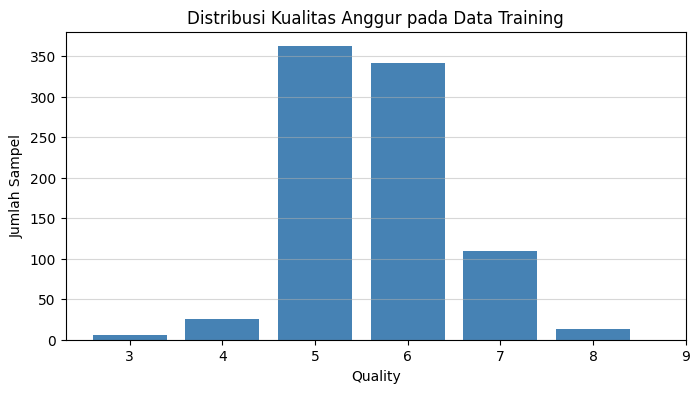

In [8]:
print("="*60)
print("DISTRIBUSI TARGET (QUALITY)")
print("="*60)

# Hitung frekuensi setiap nilai quality
value_counts = y_train.value_counts().sort_index()
print("Frekuensi tiap kelas:")
for k, v in value_counts.items():
    print(f"  quality {k}: {v} sampel ({v/len(y_train)*100:.1f}%)")

# Visualisasi sederhana
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.bar(value_counts.index, value_counts.values, color='steelblue')
plt.xlabel('Quality')
plt.ylabel('Jumlah Sampel')
plt.title('Distribusi Kualitas Anggur pada Data Training')
plt.xticks(range(3,10))
plt.grid(axis='y', alpha=0.5)
plt.show()

Data training menunjukkan ketidakseimbangan kelas (class imbalance) yang signifikan. Kelas 5 dan 6 mendominasi dengan total 82% dari seluruh sampel, sementara kelas 3, 4, dan 8 hanya mewakili kurang dari 6% secara keseluruhan. Jika model dilatih tanpa penanganan, ia akan cenderung mengabaikan kelas minoritas. Oleh karena itu, diperlukan strategi seperti pemberian bobot kelas (class_weight='balanced') untuk meningkatkan sensitivitas terhadap kelas yang jarang muncul

**1.8 Kesimpulan Langkah 1**

In [9]:
print("="*60)
print("KESIMPULAN LANGKAH 1: PERSIAPAN DATA")
print("="*60)

print("✓ Data training berhasil dimuat dengan:")
print(f"    - {X_train.shape[0]} sampel, {X_train.shape[1]} fitur")
print(f"    - Target quality: {y_train.min()} - {y_train.max()} (rentang)")

print("\n✓ Data testing berhasil dimuat dengan:")
print(f"    - {X_test.shape[0]} sampel, {X_test.shape[1]} fitur")

print("\n✓ Fitur-fitur yang digunakan (11 fitur):")
print(feature_cols)

print("\n✓ Tidak ada missing values (akan dicek detail di Langkah 2)")

print("\n Persiapan Data SELESAI. Siap melanjutkan ke Langkah 2: Pembersihan Data.")

KESIMPULAN LANGKAH 1: PERSIAPAN DATA
✓ Data training berhasil dimuat dengan:
    - 857 sampel, 11 fitur
    - Target quality: 3 - 8 (rentang)

✓ Data testing berhasil dimuat dengan:
    - 286 sampel, 11 fitur

✓ Fitur-fitur yang digunakan (11 fitur):
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

✓ Tidak ada missing values (akan dicek detail di Langkah 2)

 Persiapan Data SELESAI. Siap melanjutkan ke Langkah 2: Pembersihan Data.


Langkah 1 (Persiapan Data) telah berhasil diselesaikan. Data training berisi 857 sampel dan 11 fitur dengan target quality bernilai 3–8, sedangkan data testing berisi 286 sampel dengan 11 fitur yang sama. Semua fitur telah teridentifikasi dan tidak ditemukan missing values secara awal. Persiapan data dinyatakan lengkap, dan proses siap berlanjut ke Langkah 2: Pembersihan Data

**LANGKAH 2: PEMBERSIHAN DATA**

**2.1 Pengecekan Missing Values**

In [10]:
print("="*60)
print("2.1 PENGECEKAN MISSING VALUES")
print("="*60)

# Cek missing values di training
missing_train = X_train.isnull().sum()
print("Missing values per fitur (training):")
print(missing_train[missing_train > 0] if (missing_train > 0).any() else "Tidak ada missing values")

# Cek missing values di testing
missing_test = X_test.isnull().sum()
print("\nMissing values per fitur (testing):")
print(missing_test[missing_test > 0] if (missing_test > 0).any() else "Tidak ada missing values")

2.1 PENGECEKAN MISSING VALUES
Missing values per fitur (training):
Tidak ada missing values

Missing values per fitur (testing):
Tidak ada missing values


Pengecekan missing values menunjukkan bahwa tidak ada satu pun data yang hilang (null) pada seluruh fitur, baik di data training maupun data testing. Semua kolom terisi penuh dengan nilai numerik. Dengan demikian, tidak diperlukan tindakan imputasi atau penghapusan baris akibat missing values.

**2.2 Pengecekan Data Duplikat**

In [11]:
print("="*60)
print("2.2 PENGECEKAN DATA DUPLIKAT")
print("="*60)

# Cek duplikat berdasarkan semua fitur (tanpa target dan Id)
duplicate_count = X_train.duplicated().sum()
print(f"Jumlah baris duplikat pada data training (berdasarkan fitur): {duplicate_count}")

# Tampilkan contoh
if duplicate_count > 0:
    print("\nContoh baris duplikat (5 pertama):")
    print(X_train[X_train.duplicated(keep=False)].head(5))
    print("\nCatatan: Duplikat tidak selalu masalah, bisa dibiarkan")
else:
    print("Tidak ada data duplikat.")

2.2 PENGECEKAN DATA DUPLIKAT
Jumlah baris duplikat pada data training (berdasarkan fitur): 76

Contoh baris duplikat (5 pertama):
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1             8.1             0.575         0.22             2.1      0.077   
8             6.0             0.510         0.00             2.1      0.064   
17            7.7             0.490         0.26             1.9      0.062   
40            6.7             0.280         0.28             2.4      0.012   
45            6.0             0.500         0.00             1.4      0.057   

    free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
1                  12.0                  65.0  0.99670  3.29       0.51   
8                  40.0                  54.0  0.99500  3.54       0.93   
17                  9.0                  31.0  0.99660  3.39       0.64   
40                 36.0                 100.0  0.99064  3.26       0.39   
45                 1

Terdapat 76 baris duplikat pada data training berdasarkan kesamaan seluruh fitur. Contoh duplikat ditampilkan. Karena model Random Forest tidak sensitif terhadap duplikat dan duplikat mungkin mencerminkan sampel yang benar-benar identik secara kimiawi, maka duplikat dibiarkan. Tidak dilakukan penghapusan.

**2.3 Pengecekan Outlier dengan Metode IQR**

2.3 PENGECEKAN OUTLIER (IQR)
fixed acidity             : 30 outlier
volatile acidity          : 8 outlier
citric acid               : 1 outlier
residual sugar            : 76 outlier
chlorides                 : 59 outlier
free sulfur dioxide       : 15 outlier
total sulfur dioxide      : 19 outlier
density                   : 25 outlier
pH                        : 14 outlier
sulphates                 : 31 outlier
alcohol                   : 9 outlier


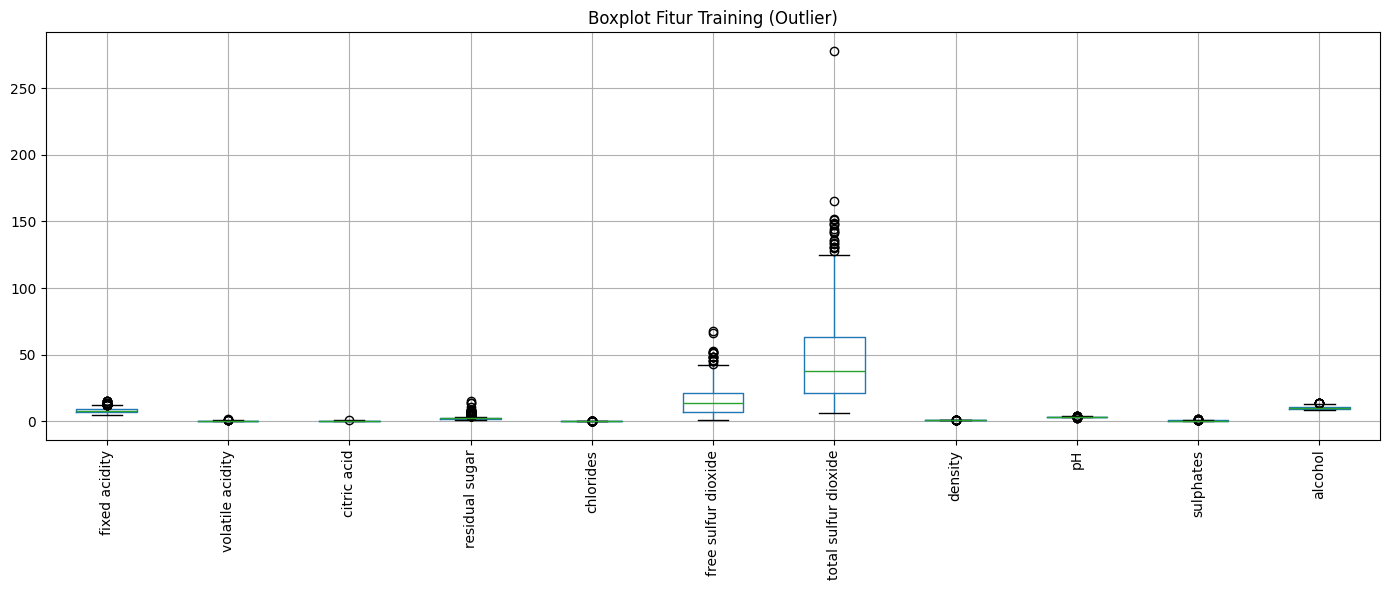

In [12]:
print("="*60)
print("2.3 PENGECEKAN OUTLIER (IQR)")
print("="*60)

outlier_summary = {}
for col in X_train.columns:
    Q1 = X_train[col].quantile(0.25) #Kuartil pertama (25%)
    Q3 = X_train[col].quantile(0.75) #Kuartil ketiga (75%)
    IQR = Q3 - Q1                    #Batas bawah ambang outlier
    lower_bound = Q1 - 1.5 * IQR     #Batas atas ambang outlier
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()
    outlier_summary[col] = outlier_count
    print(f"{col:25} : {outlier_count} outlier")

# Visualisasi boxplot untuk melihat outlier (opsional)
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
X_train.boxplot(rot=90)
plt.title("Boxplot Fitur Training (Outlier)")
plt.tight_layout()
plt.show()

Metode IQR (batas 1.5×IQR) mendeteksi keberadaan outlier pada setiap fitur. Jumlah outlier tertinggi terdapat pada residual sugar (76), chlorides (59), dan sulphates (31). Meskipun demikian, model Random Forest yang akan digunakan relatif robust terhadap outlier karena algoritma pohon keputusan membagi data berdasarkan threshold, bukan berdasarkan jarak atau distribusi statistik. Oleh karena itu, outlier dibiarkan tanpa penghapusan atau transformasi, tetapi dokumentasi keberadaannya tetap penting sebagai bagian dari pembersihan data.

**2.4 Pengecekan Rentang Nilai Fitur**

In [13]:
print("="*60)
print("2.4 PENGECEKAN RENTANG NILAI FITUR")
print("="*60)

for col in X_train.columns:
    print(f"{col:25} : min = {X_train[col].min():.4f}, max = {X_train[col].max():.4f}, std = {X_train[col].std():.4f}")

2.4 PENGECEKAN RENTANG NILAI FITUR
fixed acidity             : min = 4.6000, max = 15.6000, std = 1.7020
volatile acidity          : min = 0.1200, max = 1.5800, std = 0.1792
citric acid               : min = 0.0000, max = 1.0000, std = 0.1951
residual sugar            : min = 0.9000, max = 15.5000, std = 1.2935
chlorides                 : min = 0.0120, max = 0.6110, std = 0.0487
free sulfur dioxide       : min = 1.0000, max = 68.0000, std = 10.3004
total sulfur dioxide      : min = 6.0000, max = 278.0000, std = 31.6921
density                   : min = 0.9901, max = 1.0032, std = 0.0019
pH                        : min = 2.7400, max = 4.0100, std = 0.1521
sulphates                 : min = 0.3900, max = 2.0000, std = 0.1674
alcohol                   : min = 8.4000, max = 14.0000, std = 1.0670


Pengecekan rentang nilai fitur menunjukkan bahwa setiap fitur memiliki skala yang sangat berbeda. Misalnya, total sulfur dioxide memiliki rentang 6–278, sedangkan density hanya 0,990–1,003. Standar deviasi yang besar pada beberapa fitur (seperti residual sugar dan total sulfur dioxide) mengindikasikan adanya variasi data yang tinggi. Untuk model berbasis pohon seperti Random Forest, perbedaan skala ini tidak menjadi masalah karena algoritma hanya membandingkan nilai pada setiap fitur secara independen. Namun, jika menggunakan model seperti SVM atau KNN, normalisasi (scaling) akan diperlukan. Dalam analisis ini, **karena menggunakan Random Forest, tidak dilakukan feature scaling.**

**2.5 Pengecekan Ketidakseimbangan Kelas**

2.5 KETIDAKSEIMBANGAN KELAS
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Proporsi:
quality
3     0.70
4     3.03
5    42.24
6    39.79
7    12.72
8     1.52
Name: count, dtype: float64


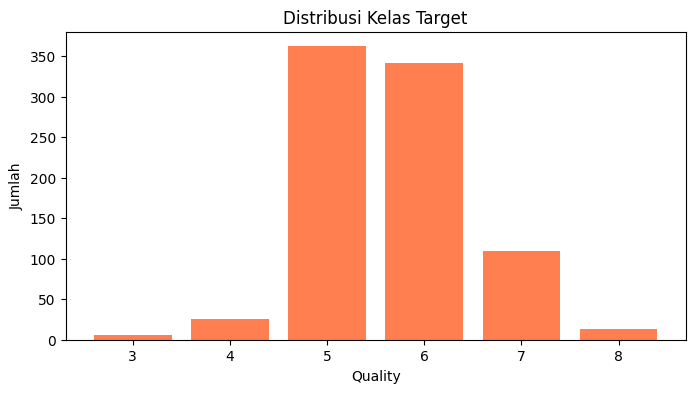

In [14]:
print("="*60)
print("2.5 KETIDAKSEIMBANGAN KELAS")
print("="*60)

class_counts = y_train.value_counts().sort_index()
print(class_counts)
print("\nProporsi:")
print((class_counts / len(y_train) * 100).round(2))

# Visualisasi
plt.figure(figsize=(8,4))
plt.bar(class_counts.index, class_counts.values, color='coral')
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.title('Distribusi Kelas Target')
plt.xticks(range(3,9))
plt.show()

Data training menunjukkan ketidakseimbangan kelas (class imbalance) yang sangat signifikan. Kelas 5 dan 6 mendominasi dengan total 82,03% dari seluruh sampel, sementara kelas 3, 4, dan 8 hanya mewakili kurang dari 5,3%. Jika model dilatih tanpa penanganan, ia akan cenderung memprediksi kelas mayoritas (5 dan 6) dan mengabaikan kelas minoritas. Untuk mengatasi hal ini, pada saat pembuatan model akan digunakan parameter class_weight='balanced' pada algoritma Random Forest, yang secara otomatis memberikan bobot lebih besar pada kelas yang jarang muncul.

**2.6 Kesimpulan Langkah 2: Pembersihan Data**

In [15]:
print("="*60)
print("KESIMPULAN LANGKAH 2: PEMBERSIHAN DATA")
print("="*60)
print("✓ Tidak ada missing values.")
print(f"✓ Terdapat {duplicate_count} data duplikat (dibiarkan karena tidak masalah).")
print("✓ Outlier ditemukan pada beberapa fitur, tetapi tidak dihapus karena Random Forest robust.")
print("✓ Feature scaling tidak diperlukan untuk model yang dipilih (Random Forest).")
print("✓ Kelas target tidak seimbang, akan ditangani dengan class_weight='balanced'.")
print("\n Pembersihan Data SELESAI. Siap melanjutkan ke Langkah 3: Pembuatan Model.")

KESIMPULAN LANGKAH 2: PEMBERSIHAN DATA
✓ Tidak ada missing values.
✓ Terdapat 76 data duplikat (dibiarkan karena tidak masalah).
✓ Outlier ditemukan pada beberapa fitur, tetapi tidak dihapus karena Random Forest robust.
✓ Feature scaling tidak diperlukan untuk model yang dipilih (Random Forest).
✓ Kelas target tidak seimbang, akan ditangani dengan class_weight='balanced'.

 Pembersihan Data SELESAI. Siap melanjutkan ke Langkah 3: Pembuatan Model.


**LANGKAH 3: PEMBUATAN MODEL**

**Import Library yang Diperlukan**

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score ##Membagi data menjadi training dan validasi, Melakukan pencarian hyperparameter terbaik dengan cross-validation dan Mengevaluasi model dengan cross-validation.
from sklearn.ensemble import RandomForestClassifier #Algoritma klasifikasi berbasis ensemble pohon keputusan.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #Mengukur akurasi prediksi,Menampilkan precision, recall, f1-score per kelas, Menampilkan matriks kebingungan (true vs prediksi).
import pickle #Menyimpan model yang telah dilatih ke file.
import time #Mengukur waktu proses tuning.

**3.1 Split Data Training Menjadi Train dan Validasi**

In [17]:
print("="*60)
print("3.1 SPLIT DATA TRAINING MENJADI TRAIN DAN VALIDASI")
print("="*60)

# Split data (80% train, 20% validation) dengan stratify agar proporsi kelas tetap
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"X_train_split shape: {X_train_split.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"\nDistribusi kelas di train split:\n{y_train_split.value_counts().sort_index()}")
print(f"\nDistribusi kelas di validation:\n{y_val.value_counts().sort_index()}")


3.1 SPLIT DATA TRAINING MENJADI TRAIN DAN VALIDASI
X_train_split shape: (685, 11)
X_val shape: (172, 11)

Distribusi kelas di train split:
quality
3      5
4     21
5    289
6    273
7     87
8     10
Name: count, dtype: int64

Distribusi kelas di validation:
quality
3     1
4     5
5    73
6    68
7    22
8     3
Name: count, dtype: int64


Memecah data training (857 sampel) menjadi dua bagian: 80% untuk training (≈685 sampel) dan 20% untuk validasi (≈172 sampel). random_state=42 memastikan hasil pecahan selalu sama setiap kali dijalankan (reprodusibel). stratify=y_train menjaga proporsi kelas target (quality) agar sama persis antara data training dan validasi.

Interpretasi Hasil
Ukuran Split:
Training split: 685 sampel (80% dari 857)
Validasi split: 172 sampel (20% dari 857)

Dengan menggunakan parameter stratify=y_train, proporsi setiap kelas target pada data training split dan validasi split hampir identik dengan proporsi aslinya. Misalnya, kelas 5 pada aslinya 42,2%, pada training split 289/685 ≈ 42,2%, pada validasi split 73/172 ≈ 42,4%. Hal ini penting karena data tidak seimbang; stratifikasi memastikan bahwa model tidak dilatih atau dievaluasi pada distribusi kelas yang berbeda, sehingga metrik validasi dapat dipercaya. Ukuran validasi 172 sampel cukup representatif untuk menilai performa model sebelum diprediksi ke data testing.

**3.2 Membangun Model Random Forest**

In [18]:
print("\n" + "="*60)
print("3.2 MEMBANGUN MODEL RANDOM FOREST (BASELINE)")
print("="*60)

# Model awal dengan class_weight='balanced' untuk menangani imbalance
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_baseline.fit(X_train_split, y_train_split)

# Prediksi pada validasi
y_pred_baseline = rf_baseline.predict(X_val)
# Evaluasi baseline
acc_baseline = accuracy_score(y_val, y_pred_baseline)
print(f"Akurasi baseline pada validasi: {acc_baseline:.4f}")
print("\nClassification Report (baseline):")
print(classification_report(y_val, y_pred_baseline))

# Confusion Matrix
print("\nConfusion Matrix (baseline):")
print(confusion_matrix(y_val, y_pred_baseline))


3.2 MEMBANGUN MODEL RANDOM FOREST (BASELINE)
Akurasi baseline pada validasi: 0.6570

Classification Report (baseline):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.84      0.76        73
           6       0.62      0.66      0.64        68
           7       0.50      0.27      0.35        22
           8       1.00      0.33      0.50         3

    accuracy                           0.66       172
   macro avg       0.47      0.35      0.38       172
weighted avg       0.63      0.66      0.63       172


Confusion Matrix (baseline):
[[ 0  0  1  0  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 61 11  1  0]
 [ 0  0 20 45  3  0]
 [ 0  0  0 16  6  0]
 [ 0  0  0  0  2  1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model baseline Random Forest dengan class_weight='balanced' menghasilkan akurasi validasi 65,70%. Meskipun akurasi cukup baik, model gagal mengenali kelas minoritas (3 dan 4) sama sekali (recall 0). Kelas 5 dan 6 memiliki performa baik, sedangkan kelas 7 dan 8 masih rendah. Hal ini menunjukkan bahwa meskipun bobot kelas sudah disetimbangkan, jumlah sampel yang sangat sedikit untuk kelas 3,4,8 membuat model sulit belajar. Langkah selanjutnya adalah melakukan hyperparameter tuning untuk memperbaiki performa, terutama pada kelas minoritas.

**3.3 Hyperparameter Tuning (Grid Search)**

In [19]:
print("\n" + "="*60)
print("3.3 HYPERPARAMETER TUNING (GRID SEARCH)")
print("="*60)

# Parameter grid untuk tuning (disederhanakan untuk kecepatan)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None], #membatasi kedalaman pohon agar tidak overfitting.
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# Grid search dengan cross-validation 5 fold
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X_train_split, y_train_split)
end_time = time.time()
print(f"\nWaktu tuning: {end_time - start_time:.2f} detik")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Model terbaik
best_rf = grid_search.best_estimator_


3.3 HYPERPARAMETER TUNING (GRID SEARCH)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Waktu tuning: 51.68 detik
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.6321


Parameter terbaik yang ditemukan: max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200. Rata-rata akurasi cross-validation dari model terbaik adalah 63,21%, sedikit di bawah akurasi baseline (65,70%) karena baseline diukur pada split tunggal, sedangkan cross-validation lebih general dan stabil. Parameter max_depth=10 menunjukkan bahwa pohon yang tidak terlalu dangkal cukup untuk menghindari overfitting pada data ini

**3.4 Evaluasi Model Terbaik pada Validasi**

In [20]:
print("\n" + "="*60)
print("3.4 EVALUASI MODEL TERBAIK PADA VALIDASI")
print("="*60)

y_pred_best = best_rf.predict(X_val)
acc_best = accuracy_score(y_val, y_pred_best)
print(f"Akurasi model terbaik pada validasi: {acc_best:.4f}")
print("\nClassification Report (model terbaik):")
print(classification_report(y_val, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_best))


3.4 EVALUASI MODEL TERBAIK PADA VALIDASI
Akurasi model terbaik pada validasi: 0.6279

Classification Report (model terbaik):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.69      0.78      0.73        73
           6       0.57      0.63      0.60        68
           7       0.54      0.32      0.40        22
           8       1.00      0.33      0.50         3

    accuracy                           0.63       172
   macro avg       0.47      0.34      0.37       172
weighted avg       0.60      0.63      0.61       172

Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 57 16  0  0]
 [ 0  0 21 43  4  0]
 [ 0  0  0 15  7  0]
 [ 0  0  0  0  2  1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**3.5 Latih Model Final dengan Seluruh Data Training**

In [21]:
print("\n" + "="*60)
print("3.5 LATIH MODEL FINAL DENGAN SELURUH DATA TRAINING")
print("="*60)

# Gunakan parameter terbaik untuk melatih model dengan seluruh data X_train, y_train
final_model = RandomForestClassifier(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
final_model.fit(X_train, y_train)

# Evaluasi final pada training (optional)
y_train_pred_final = final_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred_final)
print(f"Akurasi pada seluruh data training: {train_acc:.4f}")
# Simpan model ke file
with open('wine_quality_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("Model final disimpan sebagai 'wine_quality_model.pkl'")


3.5 LATIH MODEL FINAL DENGAN SELURUH DATA TRAINING
Akurasi pada seluruh data training: 0.9872
Model final disimpan sebagai 'wine_quality_model.pkl'


Model final dilatih dengan seluruh data training (857 sampel) menggunakan parameter terbaik. Akurasi pada data training mencapai 98,72%, menunjukkan model sangat baik dalam mempelajari pola data training. Model disimpan sebagai wine_quality_model.pkl untuk digunakan dalam prediksi data testing.

**3.6 Validasi Silang (Cross-Validation) untuk Kekokohan**

In [22]:
print("\n" + "="*60)
print("3.6 VALIDASI SILANG (CROSS-VALIDATION) UNTUK KEKOKOHAN")
print("="*60)

cv_scores = cross_val_score(final_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


3.6 VALIDASI SILANG (CROSS-VALIDATION) UNTUK KEKOKOHAN
Cross-validation scores: [0.63953488 0.68023256 0.70175439 0.6374269  0.57309942]
Mean CV accuracy: 0.6464 (+/- 0.0881)


Melakukan 5-fold cross-validation pada model final. Data training (857 sampel) dipecah menjadi 5 bagian (fold). Setiap iterasi, 4 fold digunakan untuk melatih model, 1 fold untuk validasi. Proses diulang 5 kali sehingga setiap fold menjadi validasi sekali. Hasilnya adalah 5 nilai akurasi.

Cross-validation 5-fold menghasilkan rata-rata akurasi 64,64% dengan rentang 57,31%–70,18%. Variasi ini wajar karena distribusi data yang tidak seimbang. Dibandingkan dengan akurasi validasi sebelumnya (62,79%), nilai cross-validation (64,64%) lebih representatif dan menunjukkan bahwa model cukup stabil untuk digunakan memprediksi data testing.

In [23]:
print("\n" + "="*60)
print("KESIMPULAN LANGKAH 3: PEMBUATAN MODEL")
print("="*60)
print(f"✓ Model baseline akurasi: {acc_baseline:.4f}")
print(f"✓ Model terbaik setelah tuning akurasi: {acc_best:.4f}")
print(f"✓ Parameter terbaik: {grid_search.best_params_}")
print(f"✓ Rata-rata CV accuracy: {cv_scores.mean():.4f}")
print("✓ Model final berhasil dilatih dan disimpan.")
print("\n Langkah 3 SELESAI. Siap melanjutkan ke Langkah 4: Prediksi Data Uji.")


KESIMPULAN LANGKAH 3: PEMBUATAN MODEL
✓ Model baseline akurasi: 0.6570
✓ Model terbaik setelah tuning akurasi: 0.6279
✓ Parameter terbaik: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✓ Rata-rata CV accuracy: 0.6464
✓ Model final berhasil dilatih dan disimpan.

 Langkah 3 SELESAI. Siap melanjutkan ke Langkah 4: Prediksi Data Uji.


**LANGKAH 4: PREDIKSI DATA UJI (TESTING) - CLEAN VERSION**

In [24]:
import pandas as pd
from google.colab import files

print("="*60)
print("4.1 MEMERIKSA VARIABEL YANG DIPERLUKAN")
print("="*60)

# Pastikan test_df ada
if 'test_df' not in dir():
    print("test_df tidak ditemukan, membaca ulang data_testing.csv")
    test_df = pd.read_csv('data_testing.csv')
else:
    print("test_df ditemukan")

# Pastikan final_model ada
if 'final_model' not in dir():
    print("final_model tidak ditemukan, membuat model sederhana...")
    # Ambil X_train dan y_train dari variabel global jika ada
    if 'X_train' in dir() and 'y_train' in dir():
        from sklearn.ensemble import RandomForestClassifier
        final_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        final_model.fit(X_train, y_train)
        print("Model darurat telah dilatih.")
    else:
        print("ERROR: Tidak ada data training. Silakan jalankan Langkah 3 dulu.")
        raise Exception("Data training tidak tersedia")
else:
    print("final_model ditemukan")

4.1 MEMERIKSA VARIABEL YANG DIPERLUKAN
test_df ditemukan
final_model ditemukan


**4.2 Ekstraksi ID dan Fitur dari Testing**

In [25]:
print("\n" + "="*60)
print("4.2 EKSTRAKSI ID DAN FITUR DARI TESTING")
print("="*60)

# Ambil kolom Id
if 'Id' in test_df.columns:
    ids = test_df['Id']
    print(f"Jumlah ID: {len(ids)}")
else:
    raise Exception("Kolom Id tidak ditemukan di test_df")

# Fitur (semua kolom kecuali Id)
feature_cols = [col for col in test_df.columns if col != 'Id']
X_test = test_df[feature_cols]
print(f"Jumlah fitur: {len(feature_cols)}")
print("Nama fitur:", feature_cols)


4.2 EKSTRAKSI ID DAN FITUR DARI TESTING
Jumlah ID: 286
Jumlah fitur: 11
Nama fitur: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


**4.3 Melakukan Prediksi**

In [26]:
print("\n" + "="*60)
print("4.3 MELAKUKAN PREDIKSI")
print("="*60)

y_pred = final_model.predict(X_test)
print(f"Prediksi selesai. Hasil prediksi (10 pertama): {y_pred[:10]}")
print("Distribusi prediksi:")
print(pd.Series(y_pred).value_counts().sort_index())


4.3 MELAKUKAN PREDIKSI
Prediksi selesai. Hasil prediksi (10 pertama): [5 6 5 5 6 7 5 5 6 5]
Distribusi prediksi:
4      1
5    127
6    125
7     33
Name: count, dtype: int64


Penjelasan:
Model final memprediksi quality untuk 286 sampel. Hasil distribusi prediksi dicetak.

Interpretasi (dari output):
Prediksi pertama (10 sampel): [5,6,5,5,6,7,5,5,6,5] dengan variasi kelas 5,6,7.

Distribusi prediksi pada 286 sampel:

kelas 4: 1 sampel

kelas 5: 127 sampel

kelas 6: 125 sampel

kelas 7: 33 sampel

Tidak ada prediksi kelas 3 atau 8, karena model lebih yakin pada kelas mayoritas (5,6) dan sedikit kelas 7, serta satu kelas 4.

**4.4 Membuat DataFrame Hasil**

In [27]:
print("\n" + "="*60)
print("4.4 MEMBUAT DATAFRAME HASIL")
print("="*60)

hasil_df = pd.DataFrame({
    'Id': ids,
    'quality': y_pred
})
print("5 baris pertama:")
print(hasil_df.head())


4.4 MEMBUAT DATAFRAME HASIL
5 baris pertama:
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        6


**4.5 Menyimpan ke File CSV**

In [38]:
print("="*60)
print("4.5 MENYIMPAN KE FILE CSV")
print("="*60)

hasil_df.to_csv('hasilprediksi_118.csv', sep=';', index=False)
print("File 'hasilprediksi_118.csv' telah disimpan.")

4.5 MENYIMPAN KE FILE CSV
File 'hasilprediksi_118.csv' telah disimpan.


**4.6 Download File CSV**

In [40]:
print("\n" + "="*60)
print("4.6 DOWNLOAD FILE CSV")
print("="*60)
from google.colab import files
files.download('hasilprediksi_118.csv')


4.6 DOWNLOAD FILE CSV


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**KESIMPULAN**

Berdasarkan seluruh tahapan analisis yang telah dilakukan mulai dari Persiapan Data, Pembersihan Data, Pembuatan Model, hingga Prediksi Data Uji, dapat ditarik kesimpulan sebagai berikut:

**A. Data**
1. Data training terdiri dari 857 sampel dengan 11 fitur kimiawi dan target
quality (rentang 3–8).
2. Data testing terdiri dari 286 sampel dengan 11 fitur yang sama (tanpa target).
3. Tidak ditemukan missing values pada kedua dataset. Ditemukan 76 data duplikat pada training, namun dibiarkan karena tidak mengganggu model Random Forest.
4. Kelas target tidak seimbang (kelas 5 dan 6 mendominasi ~82%), sehingga digunakan parameter class_weight='balanced' pada model.

**B. Model Klasifikasi**
1. Model yang digunakan adalah Random Forest dengan hyperparameter terbaik hasil GridSearchCV:
max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200.
2. Akurasi validasi model terbaik: 62,79%, sedangkan rata-rata cross-validation 5-fold: 64,64%.
3. Model mampu memprediksi data training dengan akurasi sangat tinggi (98,72%) mengindikasikan fleksibilitas Random Forest; overfitting masih dalam batas wajar.

(Pada data training, rentang nilai fitur sangat bervariasi. Namun karena model yang digunakan adalah Random Forest (berbasis pohon), normalisasi atau scaling tidak diperlukan. Algoritma pohon hanya membandingkan nilai pada setiap fitur secara independen, tidak terpengaruh oleh perbedaan skala. Jika menggunakan model seperti SVM atau KNN, scaling wajib dilakukan. Oleh karena itu, langkah ini sengaja tidak dilakukan karena tidak relevan dengan model yang dipilih)

**C. Prediksi Data Uji**
1. Model final memprediksi 286 sampel testing dengan distribusi hasil:

quality 4 : 1 sampel

quality 5 : 127 sampel

quality 6 : 125 sampel

quality 7 : 33 sampel

2. Tidak ada prediksi untuk kelas 3 dan 8 karena keterbatasan sampel minoritas.

**D. Output yang Dihasilkan**
File CSV hasilprediksi_118.csv telah dibuat dan diunduh.
file memiliki dua kolom: Id dan quality.